# Titanic Survival Prediction — Exploratory Data Analysis

In this notebook we explore the Titanic dataset to understand its structure, distributions, relationships between features, and patterns that might help predict survival.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

%matplotlib inline

## 2. Load the Dataset

In [3]:
df = pd.read_csv("C:/data/titanic.csv")
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head(10)

Dataset shape: 891 rows, 12 columns


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


### Column Descriptions

| Column | Description |
|--------|-------------|
| PassengerId | Unique ID for each passenger |
| Survived | 0 = Did not survive, 1 = Survived |
| Pclass | Ticket class: 1 = 1st, 2 = 2nd, 3 = 3rd |
| Name | Passenger name |
| Sex | Gender |
| Age | Age in years |
| SibSp | Number of siblings/spouses aboard |
| Parch | Number of parents/children aboard |
| Ticket | Ticket number |
| Fare | Passenger fare |
| Cabin | Cabin number |
| Embarked | Port of embarkation: C = Cherbourg, Q = Queenstown, S = Southampton |

## 3. Dataset Overview

In [4]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
# Statistical summary of numerical columns
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
# Statistical summary of categorical columns
df.describe(include="object")

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


## 4. Missing Values Analysis

In [7]:
# Count and percentage of missing values
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing["Missing Count"] > 0].sort_values("Missing %", ascending=False)
print("Columns with missing values:")
missing


Columns with missing values:


,Missing Count,Missing %
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


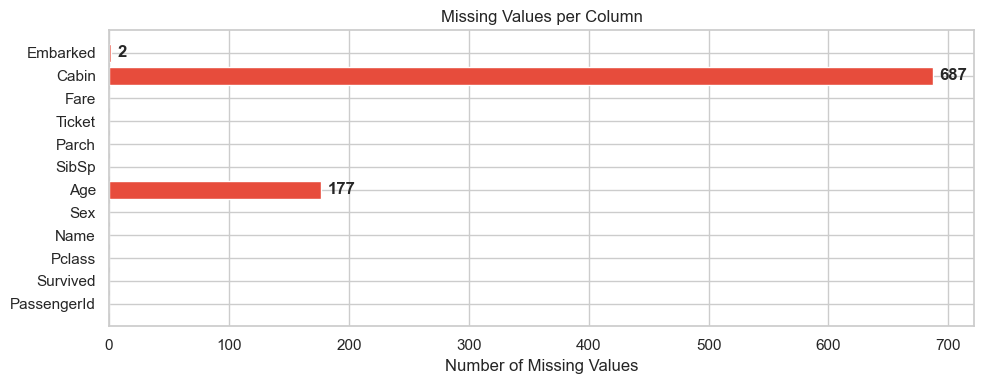

In [8]:
# Visualize missing values
fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#e74c3c" if df[col].isnull().any() else "#2ecc71" for col in df.columns]
ax.barh(df.columns, df.isnull().sum(), color=colors)
ax.set_xlabel("Number of Missing Values")
ax.set_title("Missing Values per Column")
for i, v in enumerate(df.isnull().sum()):
    if v > 0:
        ax.text(v + 5, i, str(v), va="center", fontweight="bold")
plt.tight_layout()
plt.show()


**Key observations:**
- **Cabin** has ~77% missing values — too many to impute reliably, we'll likely drop it
- **Age** has ~20% missing — we can impute using group medians
- **Embarked** has only 2 missing values — easy to fill with the mode

## 5. Target Variable Analysis

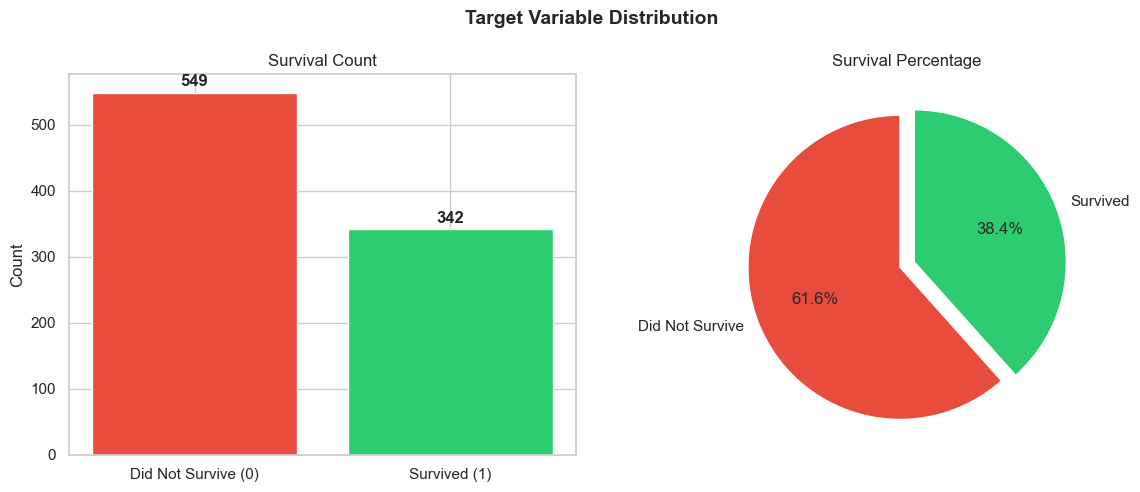


Survival rate: 38.38%
Death rate: 61.62%


In [9]:
# Survival distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
survived_counts = df["Survived"].value_counts()
axes[0].bar(["Did Not Survive (0)", "Survived (1)"], survived_counts.values,
            color=["#e74c3c", "#2ecc71"])
axes[0].set_title("Survival Count")
axes[0].set_ylabel("Count")
for i, v in enumerate(survived_counts.values):
    axes[0].text(i, v + 10, str(v), ha="center", fontweight="bold")

# Pie chart
axes[1].pie(survived_counts.values, labels=["Did Not Survive", "Survived"],
            autopct="%1.1f%%", colors=["#e74c3c", "#2ecc71"],
            startangle=90, explode=(0.05, 0.05))
axes[1].set_title("Survival Percentage")

plt.suptitle("Target Variable Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nSurvival rate: {df['Survived'].mean():.2%}")
print(f"Death rate: {1 - df['Survived'].mean():.2%}")


The dataset is **imbalanced** — about 38% survived and 62% did not. This is expected from the historical event.

## 6. Univariate Analysis — Numerical Features

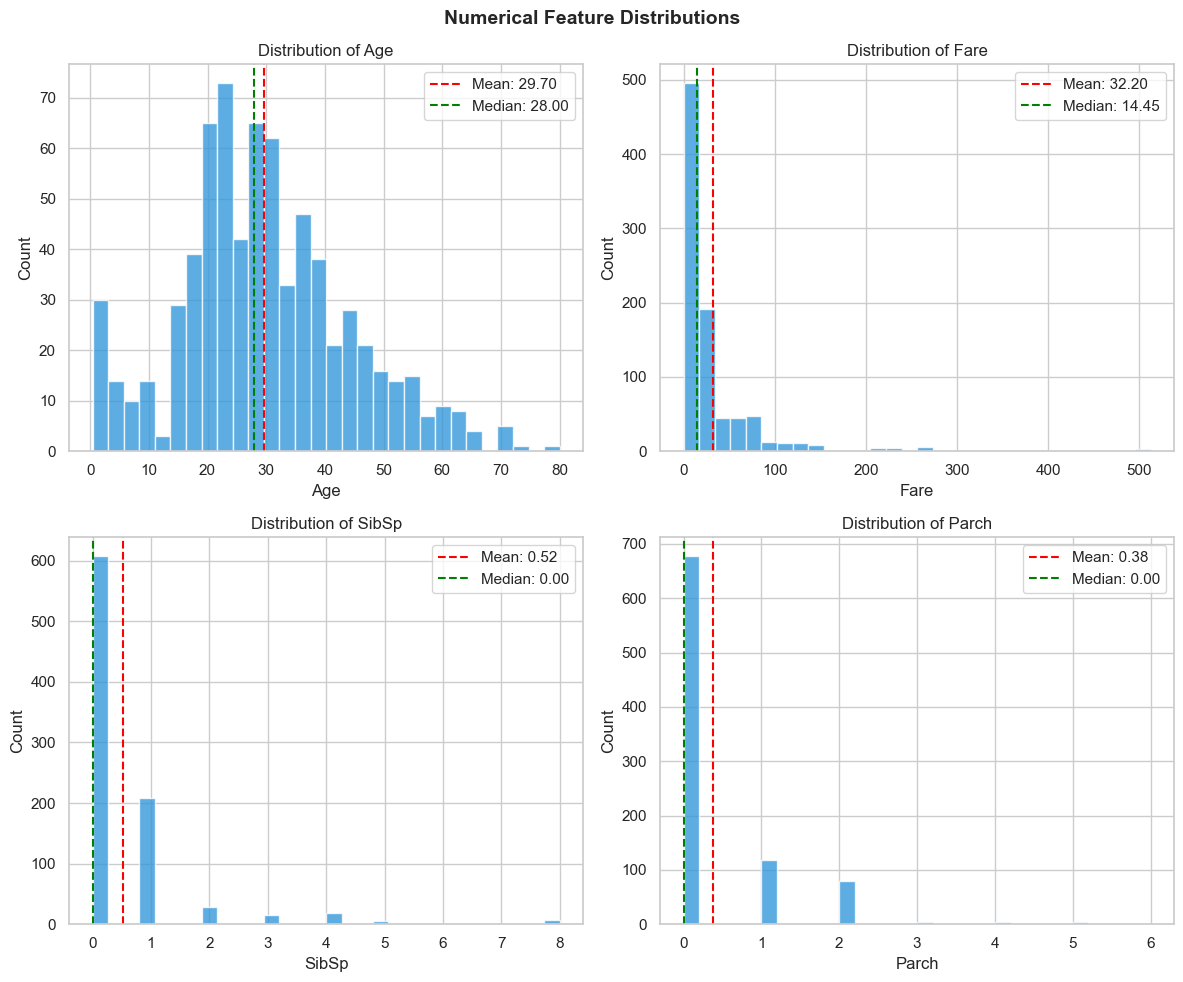

In [10]:
# Distribution of numerical features
numerical_cols = ["Age", "Fare", "SibSp", "Parch"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col].dropna(), bins=30, color="#3498db", edgecolor="white", alpha=0.8)
    axes[i].axvline(df[col].mean(), color="red", linestyle="--", label=f"Mean: {df[col].mean():.2f}")
    axes[i].axvline(df[col].median(), color="green", linestyle="--", label=f"Median: {df[col].median():.2f}")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].legend()

plt.suptitle("Numerical Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


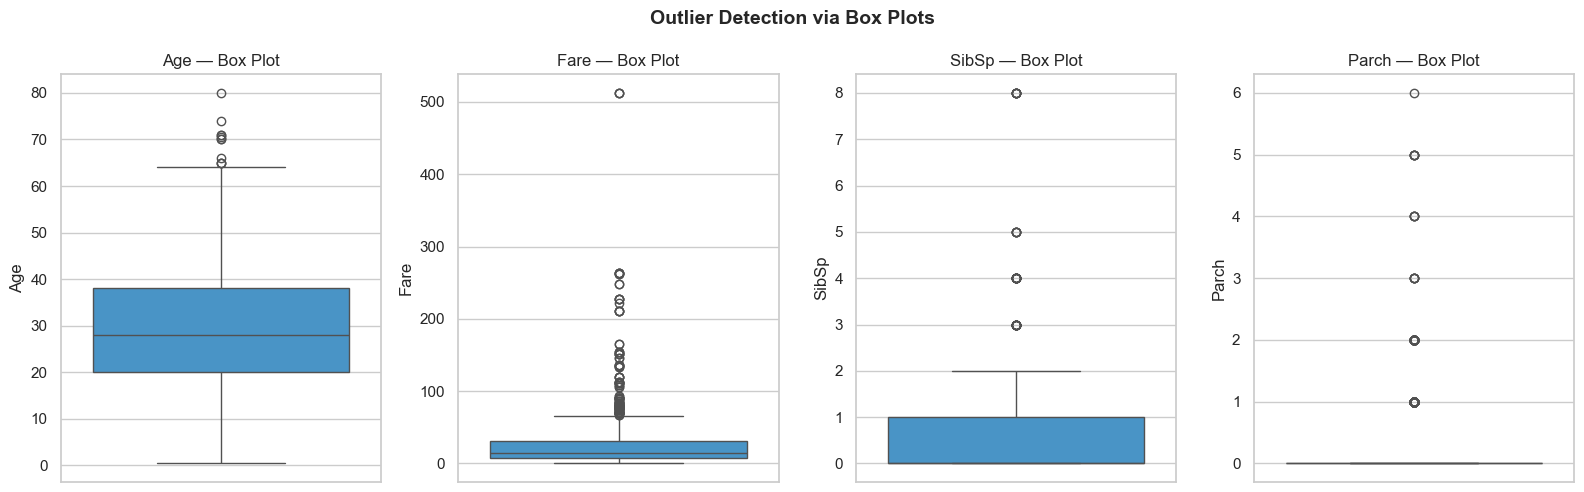

In [11]:
# Box plots to check for outliers
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="#3498db")
    axes[i].set_title(f"{col} — Box Plot")

plt.suptitle("Outlier Detection via Box Plots", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


**Observations:**
- **Age**: roughly normally distributed, centered around ~30. Some outliers at high ages.
- **Fare**: heavily right-skewed with significant outliers. A few passengers paid very high fares.
- **SibSp & Parch**: most passengers traveled alone or with 1-2 family members.

## 7. Univariate Analysis — Categorical Features

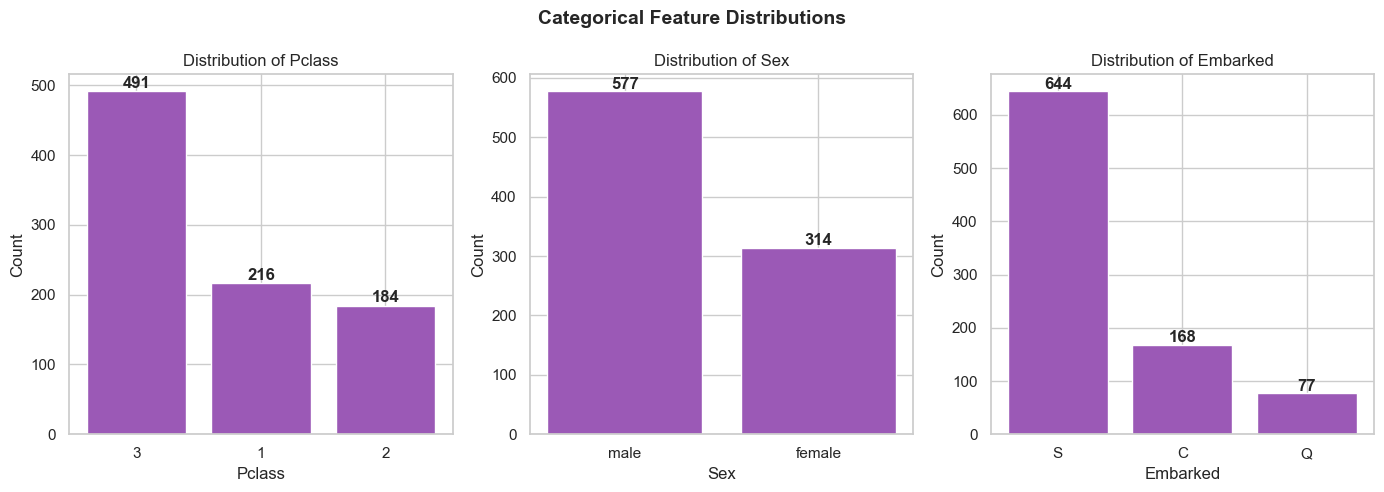

In [12]:
# Distribution of categorical features
categorical_cols = ["Pclass", "Sex", "Embarked"]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, col in enumerate(categorical_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index.astype(str), counts.values, color="#9b59b6", edgecolor="white")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 5, str(v), ha="center", fontweight="bold")

plt.suptitle("Categorical Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


**Observations:**
- **Pclass**: majority of passengers were in 3rd class
- **Sex**: more male passengers than female
- **Embarked**: most passengers boarded at Southampton (S)

## 8. Bivariate Analysis — Survival vs Features

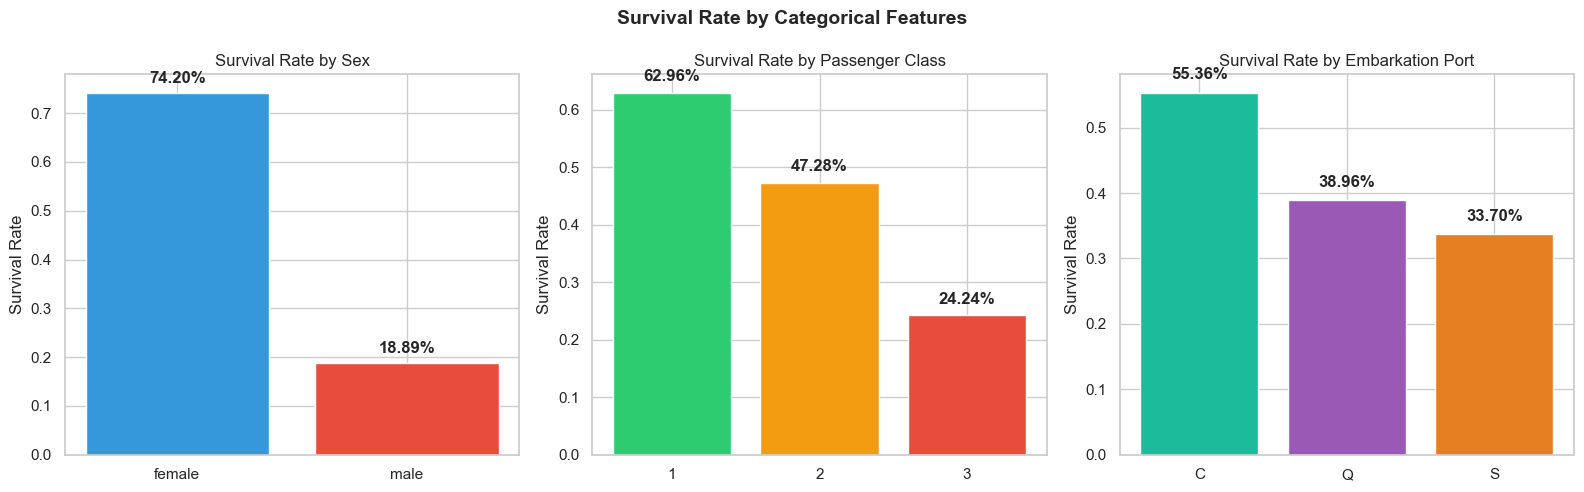

In [13]:
# Survival rate by Sex
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# By Sex
survival_by_sex = df.groupby("Sex")["Survived"].mean()
axes[0].bar(survival_by_sex.index, survival_by_sex.values, color=["#3498db", "#e74c3c"])
axes[0].set_title("Survival Rate by Sex")
axes[0].set_ylabel("Survival Rate")
for i, v in enumerate(survival_by_sex.values):
    axes[0].text(i, v + 0.02, f"{v:.2%}", ha="center", fontweight="bold")

# By Pclass
survival_by_class = df.groupby("Pclass")["Survived"].mean()
axes[1].bar(survival_by_class.index.astype(str), survival_by_class.values,
            color=["#2ecc71", "#f39c12", "#e74c3c"])
axes[1].set_title("Survival Rate by Passenger Class")
axes[1].set_ylabel("Survival Rate")
for i, v in enumerate(survival_by_class.values):
    axes[1].text(i, v + 0.02, f"{v:.2%}", ha="center", fontweight="bold")

# By Embarked
survival_by_embarked = df.groupby("Embarked")["Survived"].mean()
axes[2].bar(survival_by_embarked.index, survival_by_embarked.values,
            color=["#1abc9c", "#9b59b6", "#e67e22"])
axes[2].set_title("Survival Rate by Embarkation Port")
axes[2].set_ylabel("Survival Rate")
for i, v in enumerate(survival_by_embarked.values):
    axes[2].text(i, v + 0.02, f"{v:.2%}", ha="center", fontweight="bold")

plt.suptitle("Survival Rate by Categorical Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


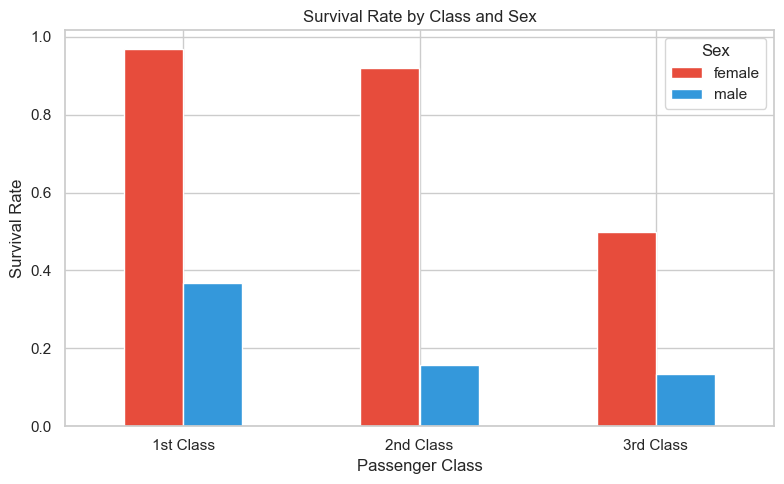

In [14]:
# Survival by Sex and Pclass combined
fig, ax = plt.subplots(figsize=(8, 5))
survival_grouped = df.groupby(["Pclass", "Sex"])["Survived"].mean().unstack()
survival_grouped.plot(kind="bar", ax=ax, color=["#e74c3c", "#3498db"])
ax.set_title("Survival Rate by Class and Sex")
ax.set_ylabel("Survival Rate")
ax.set_xlabel("Passenger Class")
ax.set_xticklabels(["1st Class", "2nd Class", "3rd Class"], rotation=0)
ax.legend(title="Sex")
plt.tight_layout()
plt.show()


**Key findings:**
- **Women had a much higher survival rate** (74%) compared to men (19%) — "women and children first"
- **1st class passengers survived at a much higher rate** (63%) than 3rd class (24%)
- **Cherbourg passengers** had the highest survival rate — likely because more 1st class passengers boarded there

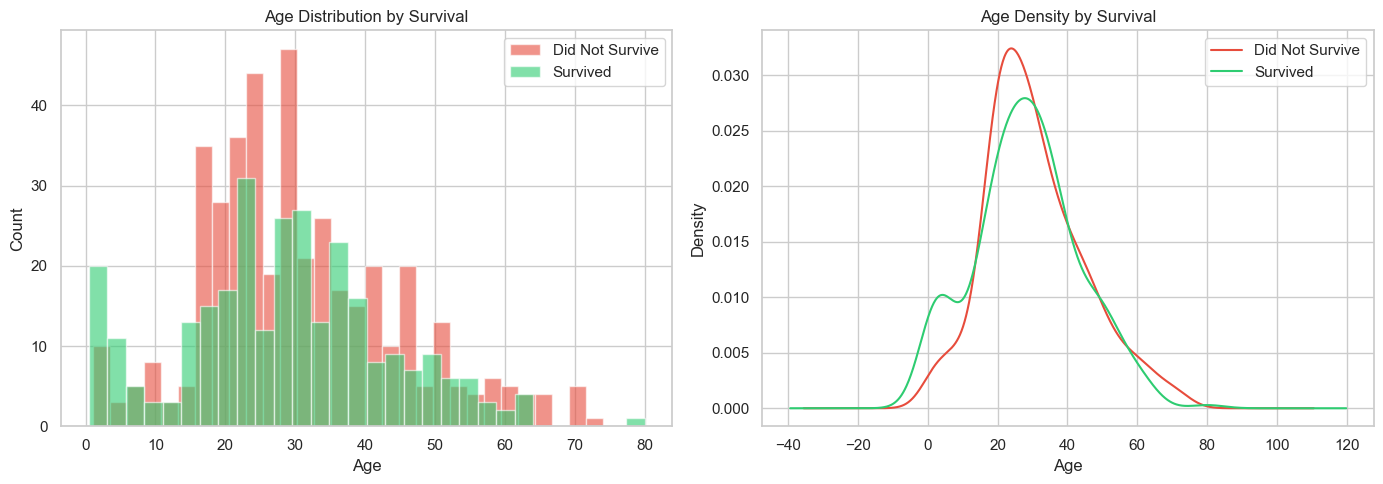

In [15]:
# Age distribution by survival
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overlapping histograms
axes[0].hist(df[df["Survived"] == 0]["Age"].dropna(), bins=30, alpha=0.6,
             color="#e74c3c", label="Did Not Survive", edgecolor="white")
axes[0].hist(df[df["Survived"] == 1]["Age"].dropna(), bins=30, alpha=0.6,
             color="#2ecc71", label="Survived", edgecolor="white")
axes[0].set_title("Age Distribution by Survival")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")
axes[0].legend()

# KDE plot
df[df["Survived"] == 0]["Age"].dropna().plot.kde(ax=axes[1], color="#e74c3c",
                                                  label="Did Not Survive")
df[df["Survived"] == 1]["Age"].dropna().plot.kde(ax=axes[1], color="#2ecc71",
                                                  label="Survived")
axes[1].set_title("Age Density by Survival")
axes[1].set_xlabel("Age")
axes[1].legend()

plt.tight_layout()
plt.show()


C:\Users\samik\AppData\Local\Temp\ipykernel_16716\2951334781.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Survived", y="Fare", data=df, palette=["#e74c3c", "#2ecc71"], ax=ax)
C:\Users\samik\AppData\Local\Temp\ipykernel_16716\2951334781.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Did Not Survive", "Survived"])


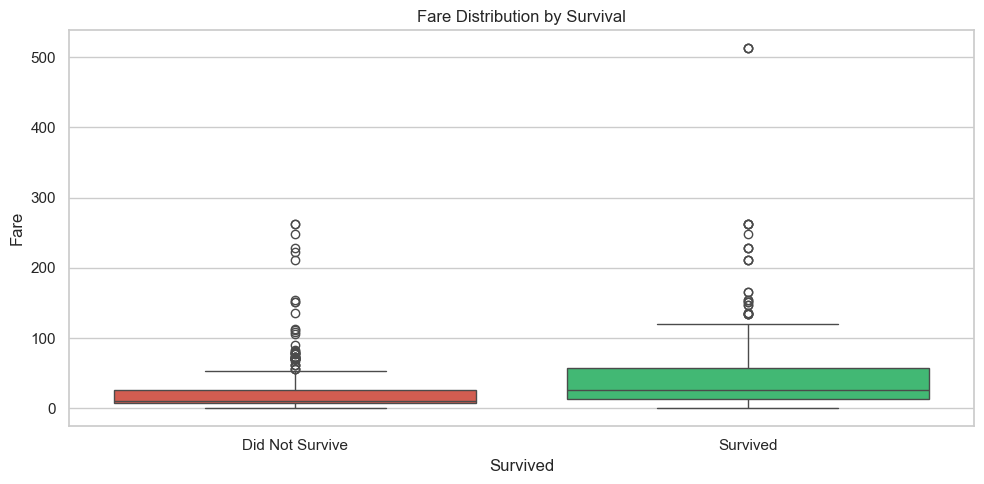

Average fare — Survived: $48.40
Average fare — Did Not Survive: $22.12


In [16]:
# Fare distribution by survival
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(x="Survived", y="Fare", data=df, palette=["#e74c3c", "#2ecc71"], ax=ax)
ax.set_xticklabels(["Did Not Survive", "Survived"])
ax.set_title("Fare Distribution by Survival")
ax.set_ylabel("Fare")
plt.tight_layout()
plt.show()

print(f"Average fare — Survived: ${df[df['Survived']==1]['Fare'].mean():.2f}")
print(f"Average fare — Did Not Survive: ${df[df['Survived']==0]['Fare'].mean():.2f}")


**Observations:**
- Children (age < 10) had a noticeably higher survival rate
- Passengers who survived paid significantly higher fares on average
- This makes sense since higher fares correlate with higher class

## 9. Family Size Analysis

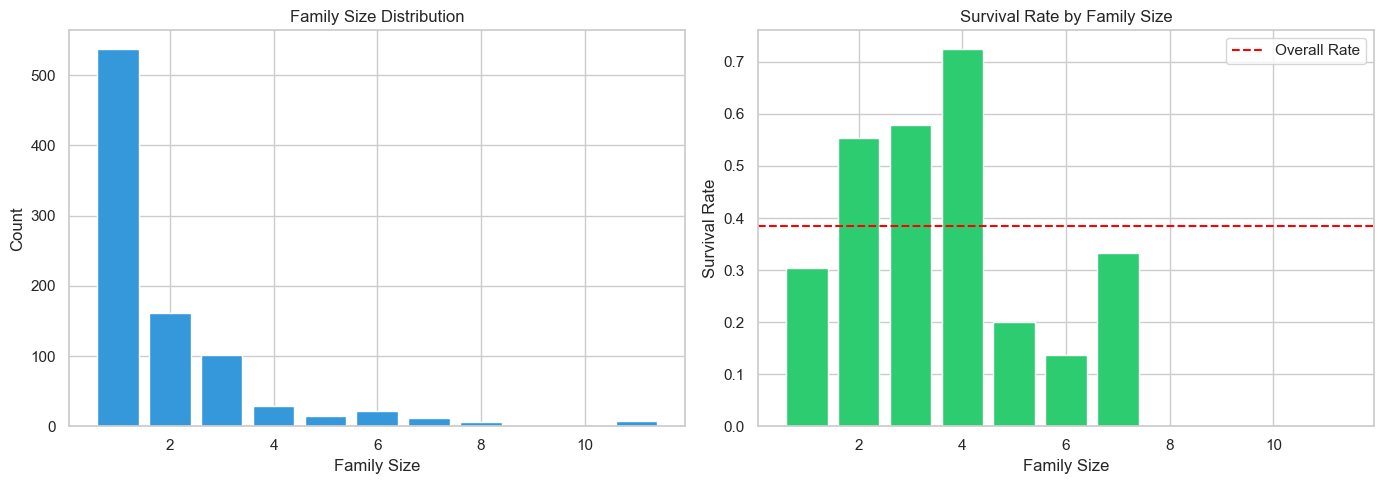

In [17]:
# Create FamilySize feature
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Family size distribution
family_counts = df["FamilySize"].value_counts().sort_index()
axes[0].bar(family_counts.index, family_counts.values, color="#3498db", edgecolor="white")
axes[0].set_title("Family Size Distribution")
axes[0].set_xlabel("Family Size")
axes[0].set_ylabel("Count")

# Survival rate by family size
survival_by_family = df.groupby("FamilySize")["Survived"].mean()
axes[1].bar(survival_by_family.index, survival_by_family.values, color="#2ecc71", edgecolor="white")
axes[1].set_title("Survival Rate by Family Size")
axes[1].set_xlabel("Family Size")
axes[1].set_ylabel("Survival Rate")
axes[1].axhline(y=df["Survived"].mean(), color="red", linestyle="--", label="Overall Rate")
axes[1].legend()

plt.tight_layout()
plt.show()


**Observation:** Passengers with small families (2-4 members) had the highest survival rates. Solo travelers and very large families had lower survival rates.

## 10. Correlation Analysis

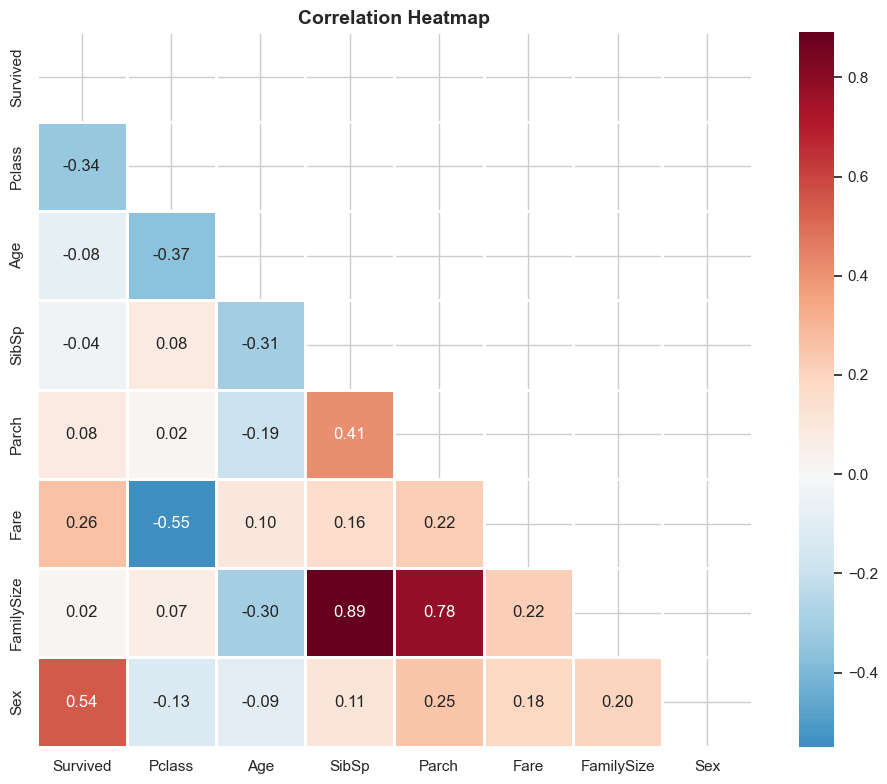

In [18]:
# Correlation heatmap of numerical features
numeric_df = df[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare", "FamilySize"]].copy()
numeric_df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))  # Upper triangle mask
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=1, ax=ax)
ax.set_title("Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


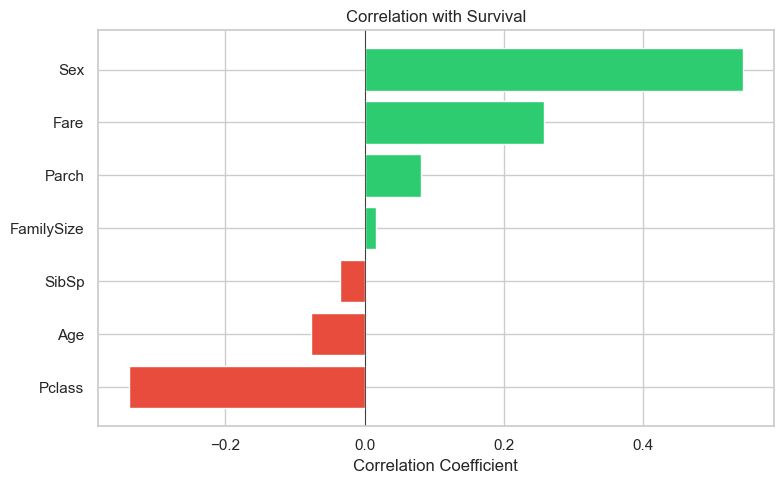

In [19]:
# Correlation with target
target_corr = corr["Survived"].drop("Survived").sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors)
ax.set_title("Correlation with Survival")
ax.set_xlabel("Correlation Coefficient")
ax.axvline(x=0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()


**Key correlations with Survival:**
- **Sex (female)**: strongest positive correlation — being female significantly increased survival chances
- **Fare**: positive correlation — higher fares (higher class) led to better survival
- **Pclass**: negative correlation — lower class number (1st class) = higher survival
- **Age**: slight negative correlation — younger passengers had slightly better chances

## 11. Title Analysis (Extracted from Name)

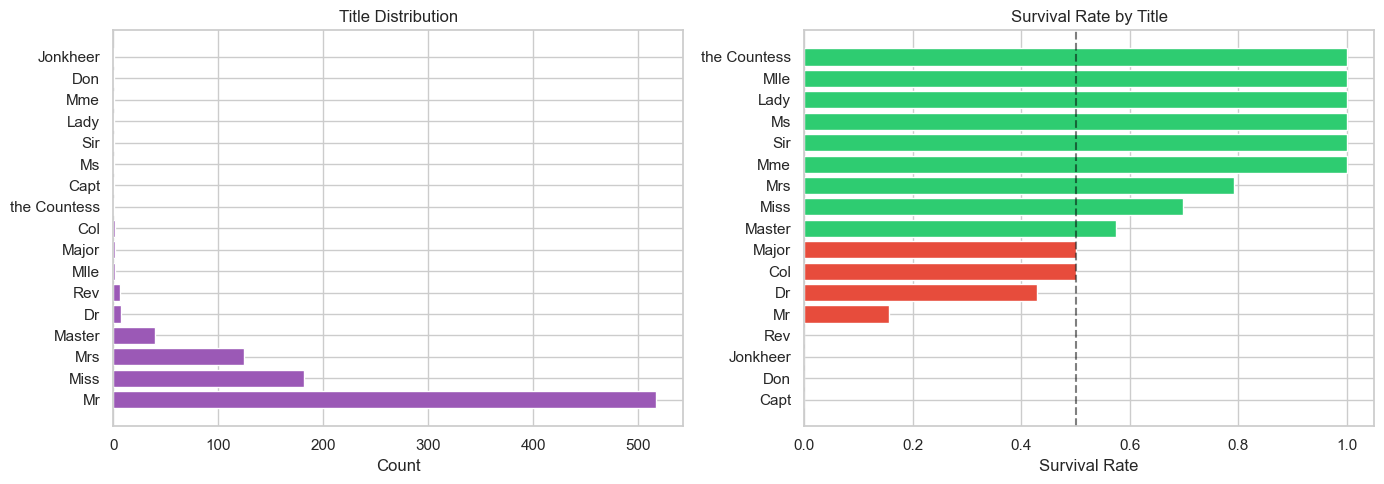

In [20]:
# Extract title from Name
df["Title"] = df["Name"].apply(lambda x: x.split(",")[1].split(".")[0].strip())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Title distribution
title_counts = df["Title"].value_counts()
axes[0].barh(title_counts.index, title_counts.values, color="#9b59b6")
axes[0].set_title("Title Distribution")
axes[0].set_xlabel("Count")

# Survival rate by title
survival_by_title = df.groupby("Title")["Survived"].mean().sort_values()
colors = ["#2ecc71" if v > 0.5 else "#e74c3c" for v in survival_by_title.values]
axes[1].barh(survival_by_title.index, survival_by_title.values, color=colors)
axes[1].set_title("Survival Rate by Title")
axes[1].set_xlabel("Survival Rate")
axes[1].axvline(x=0.5, color="black", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


## 12. Summary of EDA Findings

| Finding | Detail |
|---------|--------|
| **Class imbalance** | ~38% survived, ~62% did not |
| **Missing data** | Cabin (77%), Age (20%), Embarked (<1%) |
| **Sex is the strongest predictor** | Females survived at ~74%, males at ~19% |
| **Class matters** | 1st class: 63% survival vs 3rd class: 24% |
| **Age** | Children had higher survival; elderly had lower |
| **Fare** | Survivors paid significantly higher fares |
| **Family size** | Small families (2-4) had the best survival rates |
| **Title** | Mrs, Miss, Master had high survival; Mr had low |
| **Embarkation** | Cherbourg had higher survival (more 1st class) |
